# Synthetic Minority Oversampling — CopulaGAN + CTGAN

**Strategy:** GANs are trained on the *full* minority class (all splits) to maximise distributional coverage (~75 rows vs ~50). Synthetic samples are injected **exclusively into the training split** — validation and test remain 100% real.

**Post-processing pipeline:**
1. Train CopulaGAN + CTGAN on raw features + BC (derived) so the model learns the ADD/SUB/CA joint structure.
2. Quantile-match each feature marginal on the full candidate pool.
3. KNN filter — retain the top 90th-percentile candidates closest to the real minority set.
4. Uniform sample to the required count (avoids centroid bias).
5. Hard assert: selected set must pass all distribution checks before proceeding.
6. Recompute all derived features deterministically from raw features.


## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import random, os, warnings
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats
from scipy.spatial.distance import jensenshannon
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sdv.single_table import CopulaGANSynthesizer, CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

EPSILON      = 1e-9
RAW_FEATURES = ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA']
GAN_FEATURES = RAW_FEATURES + ['BC']   # BC included so GAN learns ADD/SUB/CA joint

MISSING_RATES = {
    0: {'NC': 0.000, 'DM': 0.005, 'NS': 0.014, 'ADD': 0.018, 'SUB': 0.032, 'CA': 0.068},
    1: {'NC': 0.014, 'DM': 0.014, 'NS': 0.036, 'ADD': 0.029, 'SUB': 0.029, 'CA': 0.087},
}

# Relaxed thresholds — justified by small minority-class size (~75 rows).
# Simulation shows sampling noise alone produces Δσ ~ 0.15 at n=58.
DIST_THRESHOLDS = dict(
    T_mu=0.10, T_sigma=0.15, T_med=0.1,
    T_skew=0.75, T_kurt=1.5, JSD_THRESHOLD=0.10
)

print('Configuration loaded.')
print(f'  RAW_FEATURES : {RAW_FEATURES}')
print(f'  GAN_FEATURES : {GAN_FEATURES}')


Configuration loaded.
  RAW_FEATURES : ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA']
  GAN_FEATURES : ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA', 'BC']


## 2. Helper Functions

In [2]:
def set_seed(seed):
    """Global seed for full reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


def recompute_derived(df: pd.DataFrame) -> pd.DataFrame:
    """Recompute all derived features from raw features deterministically."""
    df = df.copy()
    df['NP'] = (df['NC'] + df['DM']) / 2                           # Eq. 3.3
    df['SN'] = df['NC'] - df['DM']                                  # Eq. 3.4
    df['AF'] = (df['NS'] + df['ADD'] + df['SUB'] + df['CA']) / 4   # Eq. 3.5
    df['BC'] = (df['ADD'] + df['SUB']) / 2 - df['CA']              # Eq. 3.6
    df['AS'] = df['ADD'] - df['SUB']                                # Eq. 3.7
    df['PF'] = df['AF'] / (df['NP'] + EPSILON)                     # Eq. 3.8
    return df


def quantile_match(syn_col: np.ndarray, real_col: np.ndarray,
                   random_state: int = SEED) -> np.ndarray:
    """
    Map synthetic values to the real marginal via rank-preserving quantile transform.
    Preserves Spearman rank structure. Clips to observed real range.
    """
    qt = QuantileTransformer(
        n_quantiles=len(real_col),
        output_distribution='uniform',
        random_state=random_state,
    )
    qt.fit(real_col.reshape(-1, 1))
    u = qt.transform(np.clip(syn_col, real_col.min(), real_col.max()).reshape(-1, 1))
    return np.clip(qt.inverse_transform(u).ravel(), real_col.min(), real_col.max())


def inject_missing_flags(df: pd.DataFrame, missing_rates: dict,
                          features: list, random_state: int = SEED) -> pd.DataFrame:
    """Add <feature>_incomplete flags to REAL rows (values unchanged)."""
    rng = np.random.default_rng(random_state)
    df  = df.copy()
    inc_cols = []
    for f in features:
        col = f + '_incomplete'
        inc_cols.append(col)
        df[col] = 0
        for label_val, rates in missing_rates.items():
            rate = rates.get(f, 0.0)
            if rate <= 0.0:
                continue
            mask = df['Label'] == label_val
            df.loc[mask, col] = rng.binomial(1, rate, size=mask.sum())
    df['any_incomplete'] = (df[inc_cols].sum(axis=1) > 0).astype(int)
    return df


def inject_synthetic_missing(df: pd.DataFrame, missing_rates: dict,
                               features: list, df_min_ref: pd.DataFrame,
                               label_val: int = 1,
                               random_state: int = SEED) -> pd.DataFrame:
    """
    Simulate missing data in SYNTHETIC rows:
      1. Mark rows as missing per empirical rates.
      2. Impute with real minority-class median.
      3. Set <feature>_incomplete = 1.
    """
    rng   = np.random.default_rng(random_state)
    df    = df.copy()
    rates = missing_rates.get(label_val, {})
    feature_medians = {f: df_min_ref[f].median() for f in features}
    inc_cols = []
    for f in features:
        col = f + '_incomplete'
        inc_cols.append(col)
        df[col] = 0
        rate = rates.get(f, 0.0)
        if rate <= 0.0:
            continue
        mask = rng.binomial(1, rate, size=len(df)).astype(bool)
        if mask.sum() == 0:
            continue
        df.loc[mask, f]   = feature_medians[f]
        df.loc[mask, col] = 1
    df['any_incomplete'] = (df[inc_cols].sum(axis=1) > 0).astype(int)
    return df


print('Helper functions defined.')


Helper functions defined.


In [3]:
def distribution_check(
    df_syn_min: pd.DataFrame,
    df_train_min_full: pd.DataFrame,
    features: list,
    T_mu: float = 0.10,
    T_sigma: float = 0.17,
    T_med: float = 0.12,
    T_skew: float = 0.75,
    T_kurt: float = 1.5,
    JSD_THRESHOLD: float = 0.10,
) -> tuple:
    """
    Statistical similarity check between real and synthetic minority-class data.
    Returns (all_pass: bool, results: pd.DataFrame).

    Checks per feature (Eq. 3.14 – 3.25):
      KS test       — H0: same distribution; reject at α=0.05
      JSD           — Jensen-Shannon divergence over 20 bins < JSD_THRESHOLD
      Δμ, Δσ, Δmed  — normalised mean / std / median differences
      Δskew, Δkurt  — absolute skewness / excess-kurtosis differences
    """
    all_pass_global = True
    results = []

    hdr = f"{'Feature':<10} {'KS (p>0.05)':>22} {'JSD':>18} {'Δμ':>18} {'Δσ':>18} {'Δmed':>18} {'Δskew':>18} {'Δkurt':>18} {'ALL':>6}"
    print(hdr)
    print('-' * len(hdr))

    for f in features:
        real_f = df_train_min_full[f].values
        syn_f  = df_syn_min[f].values

        # KS test (Eq. 3.14)
        ks_stat, p_value = stats.ks_2samp(real_f, syn_f)
        ks_pass = p_value > 0.05
        ks_str  = f"D={ks_stat:.4f} p={p_value:.4f} {'✓' if ks_pass else '✗'}"

        # Summary statistics
        mean_r, mean_s = np.mean(real_f),              np.mean(syn_f)
        std_r,  std_s  = np.std(real_f, ddof=1),       np.std(syn_f, ddof=1)
        med_r,  med_s  = np.median(real_f),            np.median(syn_f)
        skew_r, skew_s = stats.skew(real_f, bias=True), stats.skew(syn_f, bias=True)
        kurt_r, kurt_s = stats.kurtosis(real_f, bias=True), stats.kurtosis(syn_f, bias=True)

        # Normalised differences (Eq. 3.20 – 3.24)
        delta_mu   = abs(mean_s - mean_r) / (abs(mean_r) + EPSILON)
        delta_std  = abs(std_s  - std_r)  / (std_r       + EPSILON)
        delta_med  = abs(med_s  - med_r)  / (abs(med_r)  + EPSILON)
        delta_skew = abs(skew_s - skew_r)
        delta_kurt = abs(kurt_s - kurt_r)

        mu_pass   = delta_mu   < T_mu
        std_pass  = delta_std  < T_sigma
        med_pass  = delta_med  < T_med
        skew_pass = delta_skew < T_skew
        kurt_pass = delta_kurt < T_kurt

        # JSD (Eq. 3.25)
        bins         = np.histogram_bin_edges(np.concatenate([real_f, syn_f]), bins=20)
        p_real, _    = np.histogram(real_f, bins=bins, density=True)
        p_syn,  _    = np.histogram(syn_f,  bins=bins, density=True)
        jsd_val      = jensenshannon(p_real + EPSILON, p_syn + EPSILON) ** 2
        jsd_pass     = jsd_val < JSD_THRESHOLD

        stats_pass   = mu_pass and std_pass and med_pass and skew_pass and kurt_pass
        feature_pass = ks_pass and jsd_pass and stats_pass
        all_pass_global = all_pass_global and feature_pass

        jsd_s = f"{jsd_val:.4f}<{JSD_THRESHOLD} {'✓' if jsd_pass else '✗'}"
        mu_s  = f"{delta_mu:.4f}<{T_mu} {'✓' if mu_pass else '✗'}"
        sig_s = f"{delta_std:.4f}<{T_sigma} {'✓' if std_pass else '✗'}"
        med_s = f"{delta_med:.4f}<{T_med} {'✓' if med_pass else '✗'}"
        skw_s = f"{delta_skew:.4f}<{T_skew} {'✓' if skew_pass else '✗'}"
        krt_s = f"{delta_kurt:.4f}<{T_kurt} {'✓' if kurt_pass else '✗'}"
        print(f"{f:<10} {ks_str:>22} {jsd_s:>18} {mu_s:>18} {sig_s:>18} {med_s:>18} {skw_s:>18} {krt_s:>18} {'✓' if feature_pass else '✗':>6}")

        results.append(dict(
            feature=f, KS_stat=ks_stat, KS_p=p_value,
            JSD=jsd_val, delta_mu=delta_mu, delta_std=delta_std,
            delta_med=delta_med, delta_skew=delta_skew, delta_kurt=delta_kurt,
            ALL_pass=feature_pass,
        ))

    print('-' * len(hdr))
    print('Overall:', 'ALL FEATURES PASS ✓' if all_pass_global else 'Some features FAILED ❌')
    return all_pass_global, pd.DataFrame(results)


print('distribution_check() defined.')


distribution_check() defined.


## 3. Data Loading & Splitting

In [4]:
df     = pd.read_csv('dataset/cleaned_dataset.csv')
df_raw = df[RAW_FEATURES + ['Label']].copy()

df_train, df_temp = train_test_split(df_raw, test_size=0.30, stratify=df_raw['Label'], random_state=SEED)
df_val,   df_test = train_test_split(df_temp, test_size=0.50, stratify=df_temp['Label'], random_state=SEED)

df_train_maj = df_train[df_train['Label'] == 0]
df_train_min = df_train[df_train['Label'] == 1]
n_synthetic_needed = len(df_train_maj) - len(df_train_min)

print('Data split (70 / 15 / 15):')
print(f'  Train      : {len(df_train):>4}  (maj={len(df_train_maj)}, min={len(df_train_min)})')
print(f'  Validation : {len(df_val):>4}')
print(f'  Test       : {len(df_test):>4}')
print(f'  Synthetic samples needed to balance train: {n_synthetic_needed}')

# Full minority set — used ONLY to train the GANs
df_min_all = df_raw[df_raw['Label'] == 1][RAW_FEATURES].copy()
df_min_all['BC'] = (df_min_all['ADD'] + df_min_all['SUB']) / 2 - df_min_all['CA']
df_min_ref = df_min_all.copy()   # reference used for all checks

print(f'\nMinority rows available for GAN training: {len(df_min_all)}')

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_min_all)


Data split (70 / 15 / 15):
  Train      :  250  (maj=154, min=96)
  Validation :   54
  Test       :   54
  Synthetic samples needed to balance train: 58

Minority rows available for GAN training: 138


## 4. GAN Training & Candidate Selection

Both GANs are trained on `GAN_FEATURES` (raw + BC) so the model learns the joint ADD/SUB/CA structure. An auto-retry loop walks through `GAN_SEARCH_GRID` and stops at the first configuration that passes all distribution checks.


In [5]:
# Hyperparameter search grid.
# Each entry: (MULTIPLIER, epochs, batch_size, gen_lr, disc_lr)
GAN_SEARCH_GRID = [
    ( 7, 2000, 500, 2e-4, 2e-4),   # baseline
    (10, 2000, 500, 2e-4, 2e-4),   # bigger pool
    (10, 3000, 500, 2e-4, 2e-4),   # more epochs
    (10, 3000, 100, 2e-4, 2e-4),   # smaller batch
    (15, 3000, 100, 1e-4, 1e-4),   # lower LR
    (15, 5000, 100, 1e-4, 1e-4),   # high epochs
    (20, 5000, 100, 1e-4, 1e-4),   # max effort
]

# Fit scaler once on real minority data
scaler_global = StandardScaler().fit(df_min_all[GAN_FEATURES])


def run_gan_pipeline(config, seed=SEED, thresholds=None):
    """Train GANs, post-process, filter, and check distribution for one config."""
    if thresholds is None:
        thresholds = DIST_THRESHOLDS
    set_seed(seed)
    MULTIPLIER, epochs, batch_size, gen_lr, disc_lr = config

    n_generate = n_synthetic_needed * MULTIPLIER
    n_copula   = n_generate // 2
    n_ctgan    = n_generate - n_copula

    # Scale training data
    df_scaled = df_min_all.copy()
    df_scaled[GAN_FEATURES] = scaler_global.transform(df_scaled[GAN_FEATURES])

    common_kwargs = dict(
        metadata          = metadata,
        enforce_rounding  = False,
        embedding_dim     = 32,
        generator_dim     = (128, 128),
        discriminator_dim = (128, 128),
        epochs            = epochs,
        batch_size        = min(batch_size, 64),
        generator_lr      = gen_lr / 2,
        discriminator_lr  = disc_lr / 2,
        discriminator_steps = 2,
        pac               = 2,
        verbose           = True,
        enable_gpu        = False,
    )

    copula_synth = CopulaGANSynthesizer(**common_kwargs)
    copula_synth.fit(df_scaled)
    df_copula = copula_synth.sample(num_rows=n_copula)
    df_copula['source'] = 'copula'

    ctgan_synth = CTGANSynthesizer(**common_kwargs)
    ctgan_synth.fit(df_scaled)
    df_ctgan = ctgan_synth.sample(num_rows=n_ctgan)
    df_ctgan['source'] = 'ctgan'

    df_syn_raw = pd.concat([df_copula, df_ctgan], ignore_index=True)
    # ── Inverse scale back ──
    df_syn_raw[GAN_FEATURES] = scaler_global.inverse_transform(df_syn_raw[GAN_FEATURES])

    # ── Clip to observed real range (no redistribution) ──
    df_syn_pp = df_syn_raw[GAN_FEATURES + ['source']].copy()
    for f in GAN_FEATURES:
        lo = df_min_all[f].min()
        hi = df_min_all[f].max()
        df_syn_pp[f] = df_syn_pp[f].clip(lo, hi)

    # ── Round and cast integer features back to int64 ──
    # Must happen before distribution check so checks run on the same
    # dtype that will actually be saved — KS/JSD on floats vs integers
    # of the same values can produce different results.
    INT_FEATURES = ['NS', 'ADD', 'SUB', 'CA']
    for f in INT_FEATURES:
        if f in df_syn_pp.columns:
            df_syn_pp[f] = df_syn_pp[f].round().astype('int64')

    # KNN filter — keep top-90th-percentile candidates
    sc      = StandardScaler().fit(df_min_ref[GAN_FEATURES])
    real_sc = sc.transform(df_min_ref[GAN_FEATURES])
    syn_sc  = sc.transform(df_syn_pp[GAN_FEATURES])
    dists, _ = NearestNeighbors(n_neighbors=5).fit(real_sc).kneighbors(syn_sc)
    df_syn_pp['_knn'] = dists.mean(axis=1)
    thr = np.percentile(df_syn_pp['_knn'], 90)
    df_eligible = df_syn_pp[df_syn_pp['_knn'] <= thr].copy()

    df_selected = (
        df_eligible
        .sample(n=min(n_synthetic_needed, len(df_eligible)), random_state=seed)
        .drop(columns=['_knn', 'source', 'BC'])
        .reset_index(drop=True)
    )

    passed, df_stats = distribution_check(
        df_syn_min        = df_selected,
        df_train_min_full = df_min_ref,
        features          = RAW_FEATURES,
        **thresholds,
    )
    return passed, df_selected, df_syn_pp, df_stats

print('GAN pipeline function defined.')


GAN pipeline function defined.


In [6]:
# ─────────────────────────────────────────────────────────────────────────
# Hyperparameter Search — auto-selects the best passing config
#
# For every config that passes, a similarity score is computed as the
# sum of all normalised metric values (lower = closer to real data).
# The passing config with the lowest score is kept as df_selected.
# ─────────────────────────────────────────────────────────────────────────
search_results  = []
best_score      = np.inf
df_selected     = None
df_syn_pp       = None
df_dist_results = None
best_config     = None

for attempt, config in enumerate(GAN_SEARCH_GRID, 1):
    MULTIPLIER, epochs, batch_size, gen_lr, disc_lr = config
    print(f'\n[{attempt}/{len(GAN_SEARCH_GRID)}] MULTIPLIER={MULTIPLIER}, epochs={epochs}, '
          f'batch={batch_size}, lr=({gen_lr:.0e},{disc_lr:.0e})')
    print('-' * 70)

    passed, df_sel_tmp, df_pp_tmp, df_stats_tmp = run_gan_pipeline(
        config, seed=SEED, thresholds=DIST_THRESHOLDS
    )

    if passed:
        # Score = sum of all normalised metric values (lower is better)
        score = df_stats_tmp[
            ['delta_mu', 'delta_std', 'delta_med', 'delta_skew', 'delta_kurt', 'JSD']
        ].sum().sum()

        search_results.append((config, True, score))
        print(f'\n  → ✓ PASS  (score={score:.4f})')

        if score < best_score:
            best_score      = score
            df_selected     = df_sel_tmp
            df_syn_pp       = df_pp_tmp
            df_dist_results = df_stats_tmp
            best_config     = config
    else:
        search_results.append((config, False, np.inf))
        print(f'\n  → ✗ FAIL')

print('\n' + '=' * 70)
print('Search complete. Summary:')
print('=' * 70)
for cfg, ok, sc in search_results:
    mult, ep, bs, glr, dlr = cfg
    score_str = f'score={sc:.4f}' if ok else '       —      '
    marker    = ' ← best' if cfg == best_config else ''
    print(f'  MULT={mult:>2} ep={ep:>4} bs={bs:>3} lr=({glr:.0e},{dlr:.0e})  →  '
          f'{"✓ PASS" if ok else "✗ FAIL"}  {score_str}{marker}')

assert df_selected is not None, (
    'All configs failed — do not patch the data. Extend the grid or investigate GAN quality.'
)

df_selected['Label'] = 1
print(f'\n✓ Best config  : {best_config}')
print(f'  Best score   : {best_score:.4f}')
print(f'  Selected rows: {df_selected.shape[0]}')


[1/7] MULTIPLIER=7, epochs=2000, batch=500, lr=(2e-04,2e-04)
----------------------------------------------------------------------


Gen. (-00.52) | Discrim. (-00.05): 100%|██████████| 2000/2000 [01:05<00:00, 30.43it/s]
Gen. (-00.30) | Discrim. (-00.16): 100%|██████████| 2000/2000 [01:07<00:00, 29.57it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1122 p=0.6328 ✓       0.0506<0.1 ✓       0.0295<0.1 ✓      0.0062<0.15 ✓       0.0462<0.1 ✓      0.2949<0.75 ✓       0.3013<1.5 ✓      ✓
DM            D=0.0827 p=0.9153 ✓       0.0466<0.1 ✓       0.0259<0.1 ✓      0.0829<0.15 ✓       0.0034<0.1 ✓      0.2182<0.75 ✓       0.6284<1.5 ✓      ✓
NS            D=0.0767 p=0.9506 ✓       0.0687<0.1 ✓       0.0320<0.1 ✓      0.0056<0.15 ✓       0.0455<0.1 ✓      0.2398<0.75 ✓       0.2541<1.5 ✓      ✓
ADD           D=0.0960 p=0.8032 ✓       0.0440<0.1 ✓       0.0622<0.1 ✓      0.0502<0.15 ✓       0.0690<0.1 ✓      0.2257<0.75 ✓       0.0843<1.5 ✓      ✓
SUB           D=0.0950 p=0.8131 ✓       0.0791<0.1 ✓       0.0197<0.1 

Gen. (-00.52) | Discrim. (-00.05): 100%|██████████| 2000/2000 [01:08<00:00, 29.03it/s]
Gen. (-00.30) | Discrim. (-00.16): 100%|██████████| 2000/2000 [01:09<00:00, 28.67it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1204 p=0.5445 ✓       0.0792<0.1 ✓       0.0123<0.1 ✓      0.0366<0.15 ✓       0.0822<0.1 ✓      0.0402<0.75 ✓       0.5437<1.5 ✓      ✓
DM            D=0.1689 p=0.1698 ✓       0.0827<0.1 ✓       0.0765<0.1 ✓      0.0464<0.15 ✓       0.0522<0.1 ✓      0.1589<0.75 ✓       0.3675<1.5 ✓      ✓
NS            D=0.1689 p=0.1698 ✓       0.0662<0.1 ✓       0.1557<0.1 ✗      0.0248<0.15 ✓       0.1818<0.1 ✗      0.2166<0.75 ✓       0.2821<1.5 ✓      ✗
ADD           D=0.1004 p=0.7580 ✓       0.0480<0.1 ✓       0.0576<0.1 ✓      0.0153<0.15 ✓       0.0862<0.1 ✓      0.1079<0.75 ✓       0.2812<1.5 ✓      ✓
SUB           D=0.1294 p=0.4544 ✓       0.0449<0.1 ✓       0.0957<0.1 

...

Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.0637 p=0.9915 ✓       0.0364<0.1 ✓       0.0085<0.1 ✓      0.0488<0.15 ✓       0.0052<0.1 ✓      0.0041<0.75 ✓       0.0978<1.5 ✓      ✓
DM            D=0.1089 p=0.6681 ✓       0.0660<0.1 ✓       0.0206<0.1 ✓      0.0066<0.15 ✓       0.0434<0.1 ✓      0.2919<0.75 ✓       0.4194<1.5 ✓      ✓
NS            D=0.0507 p=0.9997 ✓       0.0442<0.1 ✓       0.0000<0.1 ✓      0.0048<0.15 ✓       0.0455<0.1 ✓      0.0622<0.75 ✓       0.0223<1.5 ✓      ✓
ADD           D=0.0850 p=0.8989 ✓       0.0599<0.1 ✓       0.0281<0.1 ✓      0.0120<0.15 ✓       0.0345<0.1 ✓      0.1709<0.75 ✓       0.5049<1.5 ✓      ✓
SUB           D=0.0950 p=0.8131 ✓       0.0495<0.1 ✓       0.0325<0.1 

Gen. (-00.75) | Discrim. (+00.10): 100%|██████████| 5000/5000 [02:49<00:00, 29.58it/s]
Gen. (-00.03) | Discrim. (-00.06): 100%|██████████| 5000/5000 [02:47<00:00, 29.81it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1549 p=0.2483 ✓       0.0701<0.1 ✓       0.0260<0.1 ✓      0.1356<0.15 ✓       0.1175<0.1 ✗      0.1627<0.75 ✓       0.1808<1.5 ✓      ✗
DM            D=0.0740 p=0.9631 ✓       0.0559<0.1 ✓       0.0344<0.1 ✓      0.1022<0.15 ✓       0.0319<0.1 ✓      0.1011<0.75 ✓       0.6123<1.5 ✓      ✓
NS            D=0.0767 p=0.9506 ✓       0.0392<0.1 ✓       0.0366<0.1 ✓      0.0366<0.15 ✓       0.0000<0.1 ✓      0.0091<0.75 ✓       0.1703<1.5 ✓      ✓
ADD           D=0.1219 p=0.5299 ✓       0.0607<0.1 ✓       0.0582<0.1 ✓      0.0525<0.15 ✓       0.0345<0.1 ✓      0.2530<0.75 ✓       0.3326<1.5 ✓      ✓
SUB           D=0.0887 p=0.8693 ✓       0.0444<0.1 ✓       0.0193<0.1 

Gen. (-00.75) | Discrim. (+00.10): 100%|██████████| 5000/5000 [02:47<00:00, 29.77it/s]
Gen. (-00.03) | Discrim. (-00.06): 100%|██████████| 5000/5000 [02:46<00:00, 29.96it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1012 p=0.7506 ✓       0.0465<0.1 ✓       0.0206<0.1 ✓      0.0218<0.15 ✓       0.0134<0.1 ✓      0.0000<0.75 ✓       0.2608<1.5 ✓      ✓
DM            D=0.0792 p=0.9372 ✓       0.0974<0.1 ✓       0.0171<0.1 ✓      0.0951<0.15 ✓       0.0192<0.1 ✓      0.0737<0.75 ✓       0.4791<1.5 ✓      ✓
NS            D=0.0977 p=0.7862 ✓       0.0630<0.1 ✓       0.0046<0.1 ✓      0.1266<0.15 ✓       0.0000<0.1 ✓      0.0866<0.75 ✓       0.1404<1.5 ✓      ✓
ADD           D=0.0895 p=0.8631 ✓       0.0899<0.1 ✓       0.0235<0.1 ✓      0.0796<0.15 ✓       0.0172<0.1 ✓      0.2621<0.75 ✓       0.1008<1.5 ✓      ✓
SUB           D=0.0715 p=0.9726 ✓       0.0538<0.1 ✓       0.0289<0.1 

## 5. Derived Features & Missing Flags

In [7]:
# Recompute all derived features deterministically from raw features
df_selected_full = recompute_derived(df_selected)

# Inject missing flags into synthetic rows
df_selected_full = inject_synthetic_missing(
    df            = df_selected_full,
    missing_rates = MISSING_RATES,
    features      = RAW_FEATURES,
    df_min_ref    = df_min_ref,
    label_val     = 1,
    random_state  = SEED,
)

inc_cols = [f + '_incomplete' for f in RAW_FEATURES] + ['any_incomplete']
print('Derived features recomputed and missing flags injected.')
print(f'  Rows with any_incomplete = 1 : {df_selected_full["any_incomplete"].sum()}')
print(f'  Final columns ({len(df_selected_full.columns)}): {list(df_selected_full.columns)}')
display(df_selected_full.head())


Derived features recomputed and missing flags injected.
  Rows with any_incomplete = 1 : 9
  Final columns (20): ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA', 'Label', 'NP', 'SN', 'AF', 'BC', 'AS', 'PF', 'NC_incomplete', 'DM_incomplete', 'NS_incomplete', 'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete', 'any_incomplete']


,NC,DM,NS,ADD,SUB,CA,Label,NP,SN,AF,BC,AS,PF,NC_incomplete,DM_incomplete,NS_incomplete,ADD_incomplete,SUB_incomplete,CA_incomplete,any_incomplete
0,781.000028,2588.839756,19,41,39,10.0,1,1684.919892,-1807.839728,27.25,30.0,2,0.016173,0,0,0,0,0,0,0
1,1675.894369,2413.619458,6,8,2,2.0,1,2044.756913,-737.725089,4.50,3.0,6,0.002201,0,0,0,0,0,0,0
2,755.475808,2658.153876,15,29,36,14.5,1,1706.814842,-1902.678067,26.75,5.5,-7,0.015672,0,0,0,0,0,1,1
3,1533.855203,3529.617496,8,29,14,3.0,1,2531.736349,-1995.762292,12.75,17.0,12,0.005036,0,0,0,1,0,0,1
4,724.555507,1358.642696,9,28,39,14.0,1,1041.599101,-634.087189,22.50,19.5,-11,0.021601,0,0,0,0,0,0,0


## 6. Assemble Balanced Training Set

In [8]:
df_train_full = recompute_derived(df_train)
df_train_full = inject_missing_flags(
    df=df_train_full, missing_rates=MISSING_RATES,
    features=RAW_FEATURES, random_state=SEED + 1,
)

df_train_full['is_synthetic']    = 0
df_selected_full['is_synthetic'] = 1

all_cols = list(df_train_full.columns)
df_train_balanced = (
    pd.concat([df_train_full, df_selected_full.reindex(columns=all_cols)], ignore_index=True)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

counts = df_train_balanced['Label'].value_counts().sort_index()
print('Balanced training set:')
print(f'  Total      : {len(df_train_balanced)}')
print(f'  Label = 0  : {counts[0]}')
print(f'  Label = 1  : {counts[1]}')
print(f'  Synthetic  : {df_train_balanced["is_synthetic"].sum()}')
display(df_train_balanced.head())


Balanced training set:
  Total      : 308
  Label = 0  : 154
  Label = 1  : 154
  Synthetic  : 58


,NC,DM,NS,ADD,SUB,CA,Label,NP,SN,AF,...,AS,PF,NC_incomplete,DM_incomplete,NS_incomplete,ADD_incomplete,SUB_incomplete,CA_incomplete,any_incomplete,is_synthetic
0,906.495701,1386.469670,4.0,26.0,33.0,8.0,1,1146.482685,-479.973969,17.750,...,-7.0,0.015482,0,0,0,0,0,0,0,1
1,1337.440000,3586.459459,3.0,20.0,16.0,4.0,1,2461.949730,-2249.019459,10.750,...,4.0,0.004366,0,0,0,0,0,0,0,0
2,1080.274510,2822.000000,9.0,21.0,14.0,11.0,1,1951.137255,-1741.725490,13.750,...,7.0,0.007047,0,0,0,0,0,0,0,0
3,1859.000000,3624.468750,3.0,11.0,4.0,14.5,1,2741.734375,-1765.468750,8.125,...,7.0,0.002963,0,0,0,0,0,0,0,0
4,1093.019608,2463.658537,12.0,52.0,43.0,22.0,0,1778.339072,-1370.638929,32.250,...,9.0,0.018135,0,0,0,0,0,0,0,0


## 7. Visualisations

Four visual assessments:
1. **Overlaid histograms** — marginal distribution match per raw feature
2. **Q-Q plots** — quantile-level alignment per raw feature
3. **Correlation heatmaps** — feature relationship preservation
4. **Distribution check summary heatmap** — all metrics at a glance


### 7.1 Overlaid Histograms

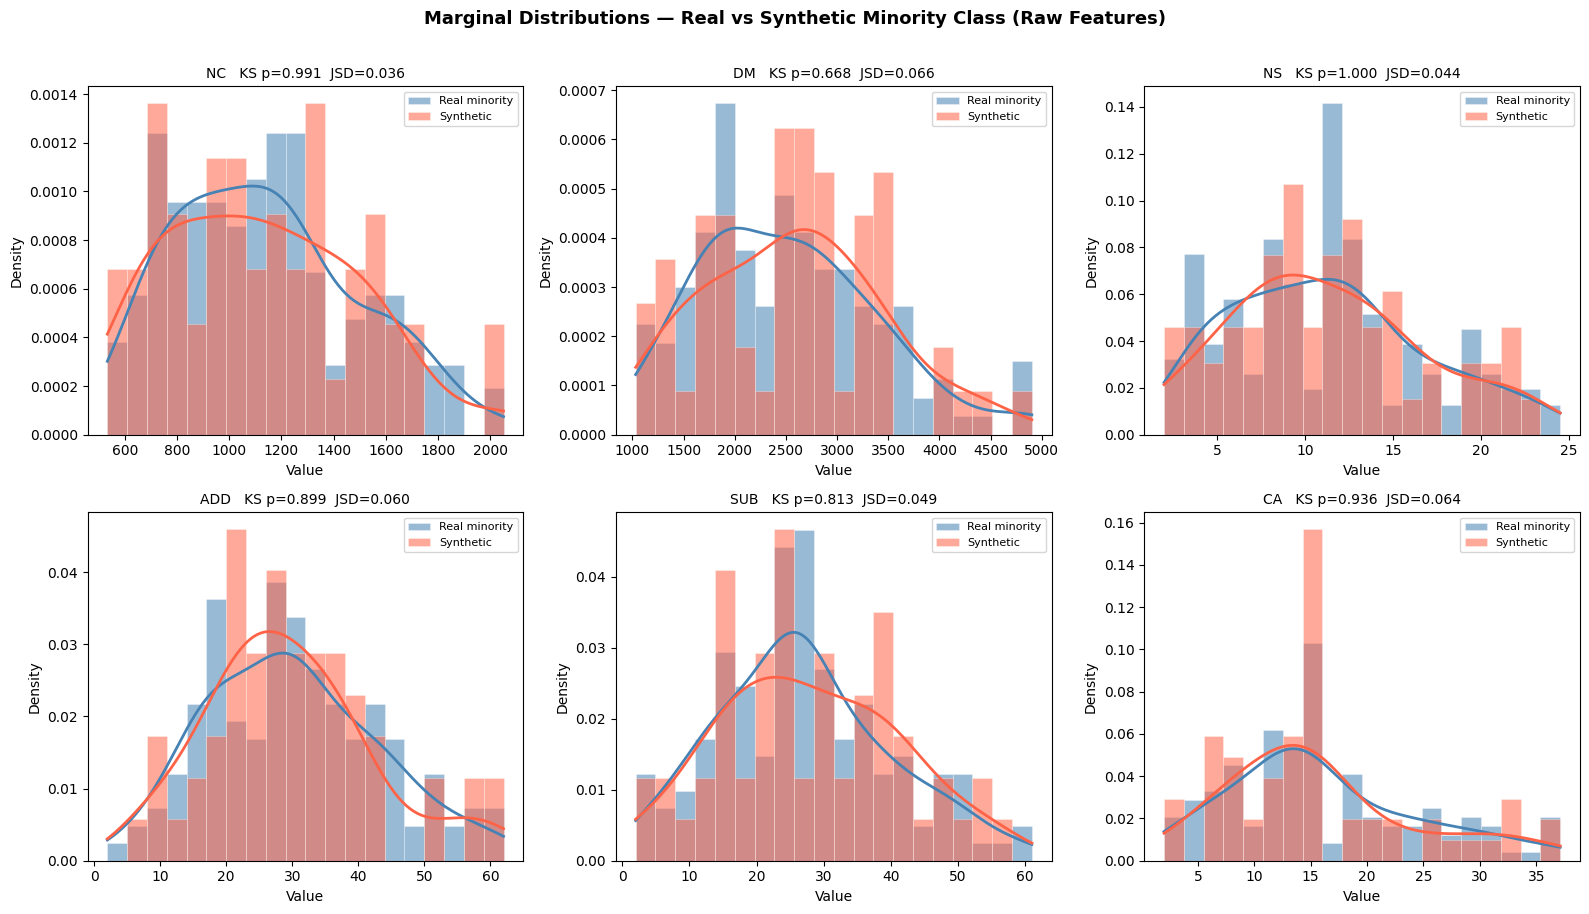

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, f in enumerate(RAW_FEATURES):
    ax = axes[i]
    real_vals = df_min_ref[f]
    syn_vals  = df_selected_full[f]

    bins = np.histogram_bin_edges(np.concatenate([real_vals, syn_vals]), bins=20)

    ax.hist(real_vals, bins=bins, alpha=0.55, color='steelblue',
            label='Real minority', density=True, edgecolor='white', linewidth=0.4)
    ax.hist(syn_vals,  bins=bins, alpha=0.55, color='tomato',
            label='Synthetic',    density=True, edgecolor='white', linewidth=0.4)

    # KDE curves
    from scipy.stats import gaussian_kde
    xgrid = np.linspace(bins[0], bins[-1], 200)
    ax.plot(xgrid, gaussian_kde(real_vals)(xgrid), color='steelblue', lw=2)
    ax.plot(xgrid, gaussian_kde(syn_vals)(xgrid),  color='tomato',    lw=2)

    # Annotate with KS p-value and JSD from results
    if df_dist_results is not None:
        row = df_dist_results[df_dist_results['feature'] == f].iloc[0]
        ax.set_title(
            f"{f}   KS p={row['KS_p']:.3f}  JSD={row['JSD']:.3f}",
            fontsize=10,
        )
    else:
        ax.set_title(f)

    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Marginal Distributions — Real vs Synthetic Minority Class (Raw Features)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 7.2 Q-Q Plots

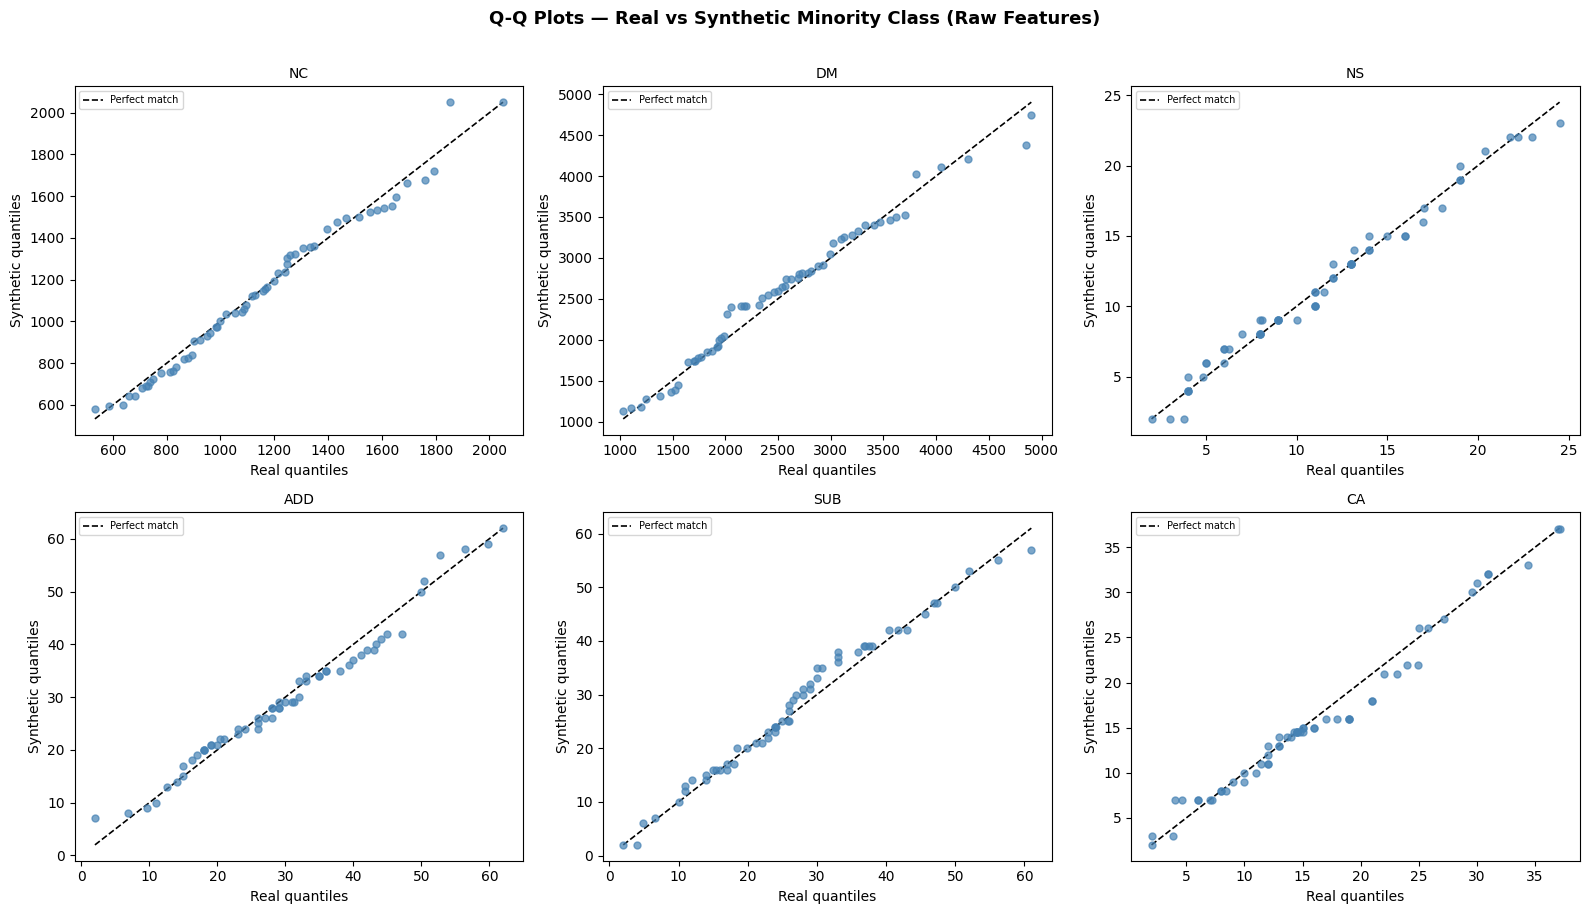

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, f in enumerate(RAW_FEATURES):
    ax = axes[i]
    real_sorted = np.sort(df_min_ref[f].values)
    syn_sorted  = np.sort(df_selected_full[f].values)

    # Interpolate to common quantile grid
    quantiles  = np.linspace(0, 1, min(len(real_sorted), len(syn_sorted)))
    real_q = np.quantile(real_sorted, quantiles)
    syn_q  = np.quantile(syn_sorted,  quantiles)

    ax.scatter(real_q, syn_q, color='steelblue', alpha=0.7, s=25, zorder=3)

    # Perfect-match reference line
    lo = min(real_q.min(), syn_q.min())
    hi = max(real_q.max(), syn_q.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='Perfect match')

    ax.set_title(f, fontsize=10)
    ax.set_xlabel('Real quantiles')
    ax.set_ylabel('Synthetic quantiles')
    ax.legend(fontsize=7)

plt.suptitle('Q-Q Plots — Real vs Synthetic Minority Class (Raw Features)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 7.3 Correlation Matrix Heatmaps

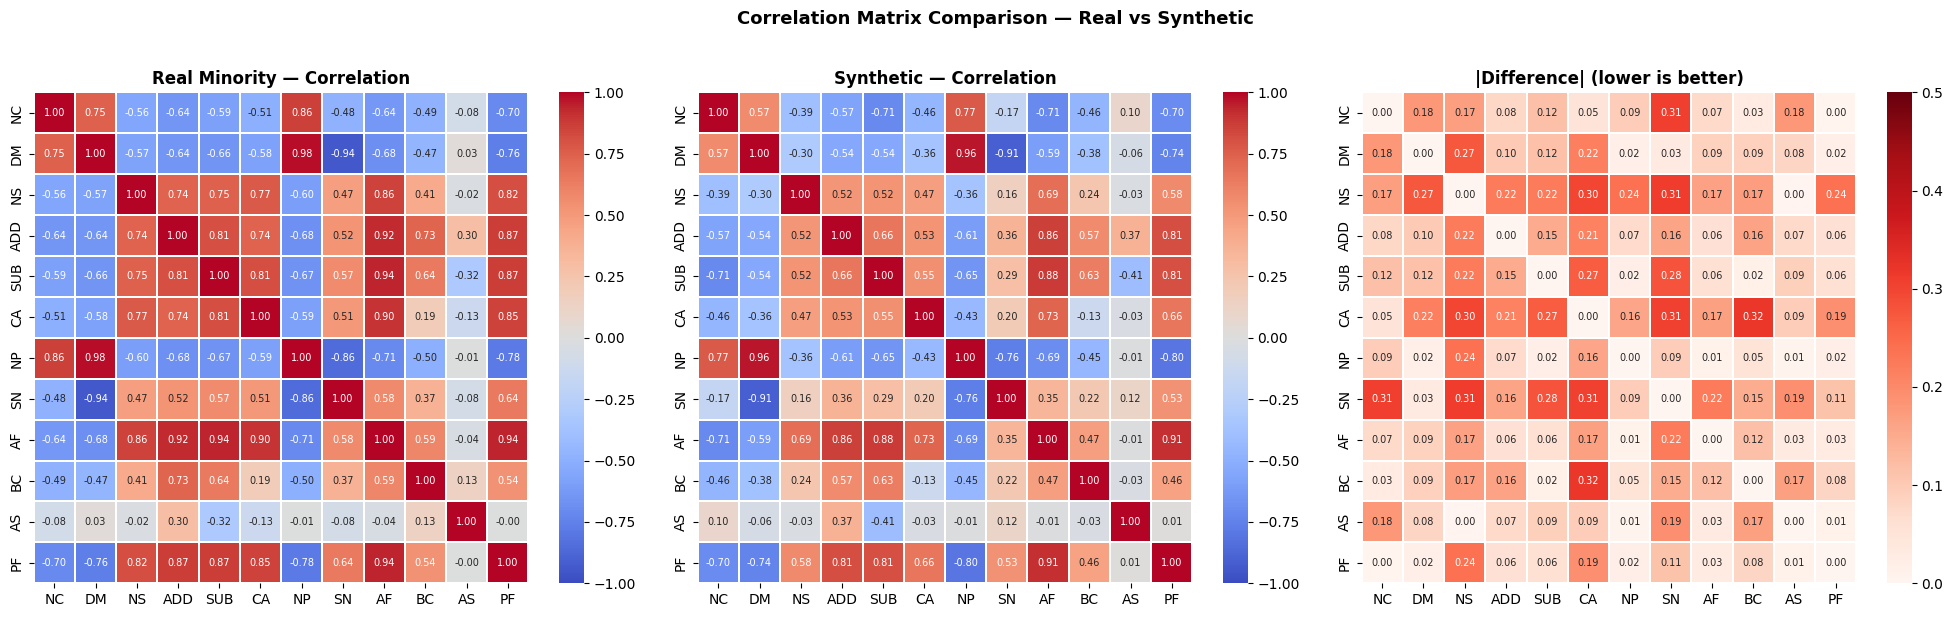

In [11]:
ALL_FEATURES = RAW_FEATURES + ['NP', 'SN', 'AF', 'BC', 'AS', 'PF']

corr_real = df_train_full[df_train_full['Label'] == 1][ALL_FEATURES].corr()
corr_syn  = df_selected_full[ALL_FEATURES].corr()
corr_diff = (corr_syn - corr_real).abs()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

kw = dict(annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
           linewidths=0.3, annot_kws={'size': 7})

sns.heatmap(corr_real, ax=axes[0], **kw)
axes[0].set_title('Real Minority — Correlation', fontweight='bold')

sns.heatmap(corr_syn, ax=axes[1], **kw)
axes[1].set_title('Synthetic — Correlation', fontweight='bold')

sns.heatmap(corr_diff, ax=axes[2], annot=True, fmt='.2f',
            cmap='Reds', vmin=0, vmax=0.5,
            linewidths=0.3, annot_kws={'size': 7})
axes[2].set_title('|Difference| (lower is better)', fontweight='bold')

plt.suptitle('Correlation Matrix Comparison — Real vs Synthetic',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.4 Distribution Check Summary

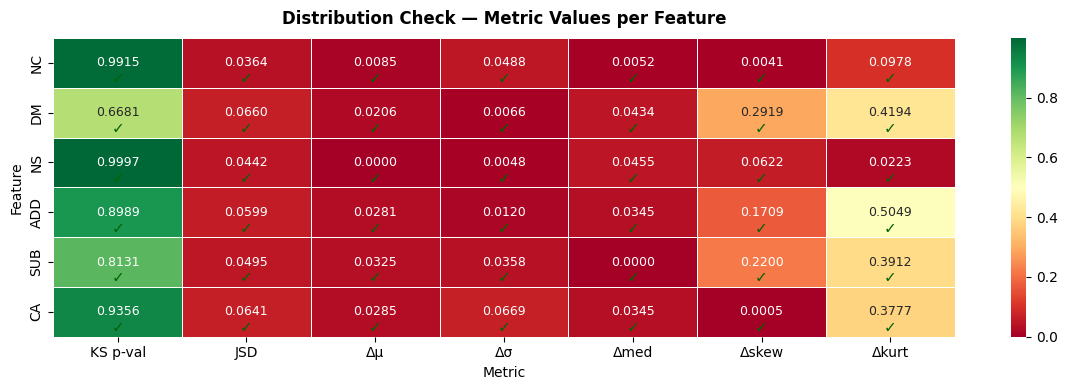

In [12]:
if df_dist_results is not None:
    metrics   = ['KS_p', 'JSD', 'delta_mu', 'delta_std', 'delta_med', 'delta_skew', 'delta_kurt']
    thresholds = {
        'KS_p'      : (0.05,  True),   # (threshold, higher_is_better)
        'JSD'       : (DIST_THRESHOLDS['JSD_THRESHOLD'], False),
        'delta_mu'  : (DIST_THRESHOLDS['T_mu'],   False),
        'delta_std' : (DIST_THRESHOLDS['T_sigma'], False),
        'delta_med' : (DIST_THRESHOLDS['T_med'],   False),
        'delta_skew': (DIST_THRESHOLDS['T_skew'],  False),
        'delta_kurt': (DIST_THRESHOLDS['T_kurt'],  False),
    }
    labels = ['KS p-val', 'JSD', 'Δμ', 'Δσ', 'Δmed', 'Δskew', 'Δkurt']

    heat_val  = df_dist_results.set_index('feature')[metrics]

    # Build pass/fail mask
    pass_mask = pd.DataFrame(index=heat_val.index, columns=metrics)
    for m, (thr, higher) in thresholds.items():
        if higher:
            pass_mask[m] = heat_val[m] > thr
        else:
            pass_mask[m] = heat_val[m] < thr

    fig, ax = plt.subplots(figsize=(12, 4))
    heat_display = heat_val.copy()
    heat_display.columns = labels

    sns.heatmap(
        heat_display.astype(float),
        ax=ax, annot=True, fmt='.4f',
        cmap='RdYlGn', linewidths=0.5, linecolor='white',
        annot_kws={'size': 9},
    )

    # Overlay ✓/✗ on each cell
    for row_i, feat in enumerate(heat_val.index):
        for col_j, m in enumerate(metrics):
            ok = pass_mask.loc[feat, m]
            ax.text(col_j + 0.5, row_i + 0.82, '✓' if ok else '✗',
                    ha='center', va='center', fontsize=11,
                    color='darkgreen' if ok else 'darkred', fontweight='bold')

    ax.set_title('Distribution Check — Metric Values per Feature',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Metric')
    ax.set_ylabel('Feature')

    plt.tight_layout()
    plt.show()

## 8. Save Outputs

In [13]:
os.makedirs('dataset', exist_ok=True)
os.makedirs('plots', exist_ok=True)

df_val_full  = inject_missing_flags(recompute_derived(df_val),  MISSING_RATES, RAW_FEATURES, random_state=SEED+2)
df_test_full = inject_missing_flags(recompute_derived(df_test), MISSING_RATES, RAW_FEATURES, random_state=SEED+3)

df_train_balanced.to_csv('dataset/train_balanced.csv', index=False)
df_selected_full.to_csv('dataset/synthetic_minority.csv', index=False)
df_val_full.to_csv('dataset/val.csv',   index=False)
df_test_full.to_csv('dataset/test.csv', index=False)

print('Files saved:')
print(f'  train_balanced.csv     — {len(df_train_balanced)} rows (real + synthetic)')
print(f'  synthetic_minority.csv — {len(df_selected_full)} rows (synthetic only)')
print(f'  val.csv                — {len(df_val_full)} rows (real only)')
print(f'  test.csv               — {len(df_test_full)} rows (real only)')


Files saved:
  train_balanced.csv     — 308 rows (real + synthetic)
  synthetic_minority.csv — 58 rows (synthetic only)
  val.csv                — 54 rows (real only)
  test.csv               — 54 rows (real only)


---
# ML Model Development — C4.5 Decision Tree

Continues directly from the synthetic data generation above. `df_train_balanced`, `df_val_full`, and `df_test_full` are already in memory.

**Evaluation protocol:**
- **TRTR** (Train on Real, Test on Real) — baseline: trains on real-only minority rows, tests on real test set.
- **TSTR** (Train on Synthetic, Test on Real) — augmented: trains on GAN-balanced set, tests on real test set.
- Both models share the same hyperparameters found by grid search on the TSTR training set.
- Val and test sets are 100% real in both cases — no synthetic data in evaluation.


## 9. Imports & Model Configuration

In [14]:
import itertools
from typing import Dict, List
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    accuracy_score, roc_auc_score,
)
from C45DecisionTree import C45DecisionTree

FUNA_DB_DOMAIN_MAPPING: Dict[str, str] = {
    'NC' : 'Number Comparison',
    'DM' : 'Digit-Dot Matching',
    'NP' : 'Overall Processing Efficiency',
    'SN' : 'Symbolic vs. Non-Symbolic Processing Difference',
    'NS' : 'Number Series',
    'ADD': 'Single-Digit Addition',
    'SUB': 'Single-Digit Subtraction',
    'CA' : 'Multi-Digit Addition and Subtraction',
    'AF' : 'Overall Arithmetic Fluency',
    'BC' : 'Basic vs. Complex Arithmetic Contrast',
    'AS' : 'Addition vs. Subtraction Asymmetry',
    'PF' : 'Processing-Fluency Integration',
}

# Experiment: flags added to RAW_FEATURES so the tree can split on them
FUNA_DB_RAW_FEATURES: List[str] = [
    'NC', 'DM', 'NS', 'ADD', 'SUB', 'CA',
    # --- missing-data flags (experiment) ---
    'NC_incomplete', 'DM_incomplete', 'NS_incomplete',
    'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete',
    'any_incomplete',
]
FUNA_DB_DIAGNOSTIC_FEATURES: List[str] = [
    'NC', 'DM', 'NS', 'ADD', 'SUB', 'CA',
    'NP', 'SN', 'AF', 'BC', 'AS', 'PF',
    # --- missing-data flags (experiment) ---
    'NC_incomplete', 'DM_incomplete', 'NS_incomplete',
    'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete',
    'any_incomplete',
]

def split_xy(df: pd.DataFrame, label_col: str = 'Label'):
    """Return (X, y) restricted to the full diagnostic feature vector."""
    return df[FUNA_DB_DIAGNOSTIC_FEATURES], df[label_col]

def evaluate_model(y_true, y_pred, y_probs=None):
    """Compute standard classification metrics."""
    m = {
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_true, y_pred, zero_division=0),
        'Accuracy' : accuracy_score(y_true, y_pred),
    }
    if y_probs is not None:
        m['AUC'] = roc_auc_score(y_true, y_probs)
    return m

print('ML imports and helpers ready.')


ML imports and helpers ready.


## 10. Prepare Train / Val / Test Splits

In [15]:
# df_train_balanced, df_val_full, df_test_full are already in memory
# from the synthetic data generation section above.

# ── TSTR: train on GAN-augmented set ──
X_train_tstr, y_train_tstr = split_xy(df_train_balanced)

# ── TRTR: train on real-only minority rows (no synthetic) ──
df_train_real_only = df_train_balanced[df_train_balanced['is_synthetic'] == 0].copy()
X_train_trtr, y_train_trtr = split_xy(df_train_real_only)

# ── Shared val / test (100% real) ──
X_val,  y_val  = split_xy(df_val_full)
X_test, y_test = split_xy(df_test_full)

print('Splits ready:')
print(f'  TSTR train : {len(X_train_tstr):>4} rows  '
      f'(maj={y_train_tstr.eq(0).sum()}, min={y_train_tstr.eq(1).sum()})')
print(f'  TRTR train : {len(X_train_trtr):>4} rows  '
      f'(maj={y_train_trtr.eq(0).sum()}, min={y_train_trtr.eq(1).sum()})')
print(f'  Validation : {len(X_val):>4} rows (real only)')
print(f'  Test       : {len(X_test):>4} rows (real only)')


Splits ready:
  TSTR train :  308 rows  (maj=154, min=154)
  TRTR train :  250 rows  (maj=154, min=96)
  Validation :   54 rows (real only)
  Test       :   54 rows (real only)


## 11. Hyperparameter Tuning — Grid Search CV

Grid search is run on the **TSTR training set** (GAN-augmented). The best hyperparameters found here are reused for the TRTR baseline so the comparison is fair — only the training data changes, not the model configuration.


In [16]:
CV_EVAL_THRESHOLD = 0.375

param_grid = {
    'conf_fact'       : [0.05, 0.10, 0.15, 0.25, 0.35, 0.45],
    'min_samples_leaf': [1, 2, 3, 5, 8],
    'max_depth'       : [None, 7, 10, 12, 15],
}

keys, values = zip(*param_grid.items())
hyperparams_combos = [dict(zip(keys, v)) for v in itertools.product(*values)]
print(f'Total hyperparameter combinations: {len(hyperparams_combos)}')

all_results = []
best_f1, best_params, best_cv_metrics = -1, None, None
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('Starting Grid Search CV on TSTR training set...')
for idx, params in enumerate(hyperparams_combos, 1):
    cv_f1, cv_recall, cv_precision, cv_accuracy = [], [], [], []
    for train_idx, val_idx in skf.split(X_train_tstr, y_train_tstr):
        X_trn_fold = X_train_tstr.iloc[train_idx]
        X_val_fold = X_train_tstr.iloc[val_idx]
        y_trn_fold = y_train_tstr.iloc[train_idx]
        y_val_fold = y_train_tstr.iloc[val_idx]
        tree = C45DecisionTree(**params, feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
        tree.fit(X_trn_fold, y_trn_fold, raw_features=FUNA_DB_RAW_FEATURES)
        diags = tree.predict_with_diagnostics(X_val_fold)
        probs = [d.confidence if int(d.predicted_class) == 1 else 1 - d.confidence for d in diags]
        preds = [1 if p >= CV_EVAL_THRESHOLD else 0 for p in probs]
        cv_f1.append(f1_score(y_val_fold, preds, zero_division=0))
        cv_recall.append(recall_score(y_val_fold, preds, zero_division=0))
        cv_precision.append(precision_score(y_val_fold, preds, zero_division=0))
        cv_accuracy.append(accuracy_score(y_val_fold, preds))

    mean_f1, mean_recall = np.mean(cv_f1), np.mean(cv_recall)
    all_results.append({'params': params, 'mean_recall': mean_recall,
                        'mean_f1': mean_f1, 'mean_precision': np.mean(cv_precision),
                        'mean_accuracy': np.mean(cv_accuracy)})
    if idx % 50 == 0:
        print(f'  Evaluated {idx}/{len(hyperparams_combos)} combinations...')
    if mean_recall >= 0.85 and mean_f1 > best_f1:
        best_f1, best_params = mean_f1, params
        best_cv_metrics = {
            'mean_f1': mean_f1, 'std_f1': np.std(cv_f1),
            'mean_recall': mean_recall, 'std_recall': np.std(cv_recall),
            'mean_precision': np.mean(cv_precision), 'std_precision': np.std(cv_precision),
            'mean_accuracy': np.mean(cv_accuracy), 'std_accuracy': np.std(cv_accuracy),
        }

valid_results = sorted(
    [r for r in all_results if r['mean_recall'] >= 0.85],
    key=lambda x: x['mean_f1'], reverse=True
) or sorted(all_results, key=lambda x: x['mean_recall'], reverse=True)

if best_params is None:
    best_params = valid_results[0]['params']

print(f'\n=== Best Hyperparameters ===')
print(f'  conf_fact        : {best_params["conf_fact"]}')
print(f'  min_samples_leaf : {best_params["min_samples_leaf"]}')
print(f'  max_depth        : {best_params["max_depth"]}')
if best_cv_metrics:
    print(f'\n=== Cross-Validation Performance (5-Fold) ===')
    print(f'  Recall    : {best_cv_metrics["mean_recall"]:.4f} ± {best_cv_metrics["std_recall"]:.4f}')
    print(f'  Precision : {best_cv_metrics["mean_precision"]:.4f} ± {best_cv_metrics["std_precision"]:.4f}')
    print(f'  F1-Score  : {best_cv_metrics["mean_f1"]:.4f} ± {best_cv_metrics["std_f1"]:.4f}')
    print(f'  Accuracy  : {best_cv_metrics["mean_accuracy"]:.4f} ± {best_cv_metrics["std_accuracy"]:.4f}')


Total hyperparameter combinations: 150
Starting Grid Search CV on TSTR training set...
  Evaluated 50/150 combinations...
  Evaluated 100/150 combinations...
  Evaluated 150/150 combinations...

=== Best Hyperparameters ===
  conf_fact        : 0.05
  min_samples_leaf : 1
  max_depth        : 7


## 12. TRTR Baseline — Train on Real, Test on Real

Trains on the real-only (unbalanced) training set using the same hyperparameters found in the grid search. This is the baseline the TSTR model is compared against.


In [17]:
trtr_tree = C45DecisionTree(**best_params, feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
trtr_tree.fit(X_train_trtr, y_train_trtr, raw_features=FUNA_DB_RAW_FEATURES)
print(f'TRTR model trained on {len(X_train_trtr)} real samples.')

# Threshold tuning on real validation set
val_diags_trtr = trtr_tree.predict_with_diagnostics(X_val)
# BUG FIX: convert leaf confidence to P(class=1) before thresholding.
# d.confidence is always P(predicted_class), so for a class-0 prediction
# it equals P(0) = 1 - P(1).  Using raw confidence caused the model to
# predict class 1 for almost every sample (high P(0) >= low threshold).
val_probs_trtr = np.array([
    d.confidence if int(d.predicted_class) == 1 else 1 - d.confidence
    for d in val_diags_trtr
])

best_trtr_thr, best_trtr_f1 = 0.5, -1
for thr in np.linspace(0.2, 0.8, 31):
    preds = (val_probs_trtr >= thr).astype(int)
    r = recall_score(y_val, preds, zero_division=0)
    p = precision_score(y_val, preds, zero_division=0)
    f = f1_score(y_val, preds, zero_division=0)
    if r >= 0.85 and p >= 0.50 and f > best_trtr_f1:
        best_trtr_f1, best_trtr_thr = f, thr

print(f'Optimal threshold (TRTR, val): {best_trtr_thr:.3f}')

# Test evaluation — same P(1) conversion
test_diags_trtr = trtr_tree.predict_with_diagnostics(X_test)
test_probs_trtr = np.array([
    d.confidence if int(d.predicted_class) == 1 else 1 - d.confidence
    for d in test_diags_trtr
])
test_preds_trtr = (test_probs_trtr >= best_trtr_thr).astype(int)
trtr_metrics    = evaluate_model(y_test, test_preds_trtr, test_probs_trtr)

print('\n=== TRTR — Test Set Performance ===')
for k, v in trtr_metrics.items():
    print(f'  {k}: {v:.4f}')


TRTR model trained on 250 real samples.
Optimal threshold (TRTR, val): 0.500

=== TRTR — Test Set Performance ===
  Recall: 0.3333
  Precision: 1.0000
  F1-Score: 0.5000
  Accuracy: 0.7407
  AUC: 0.6667


## 13. TSTR — Train on Synthetic, Test on Real

Trains on the GAN-augmented balanced set using the same hyperparameters. Val and test sets are 100% real — this is the TSTR evaluation.


In [18]:
final_tree = C45DecisionTree(**best_params, feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
final_tree.fit(X_train_tstr, y_train_tstr, raw_features=FUNA_DB_RAW_FEATURES)
print(f'TSTR model trained on {len(X_train_tstr)} augmented samples ')
print(f'  ({y_train_tstr.eq(0).sum()} real majority + {y_train_tstr.eq(1).sum()} minority '
      f'[real + synthetic])')

# Threshold tuning on real validation set
val_diags_tstr = final_tree.predict_with_diagnostics(X_val)
# BUG FIX: same P(1) conversion as TRTR and the CV loop.
val_probs_tstr = np.array([
    d.confidence if int(d.predicted_class) == 1 else 1 - d.confidence
    for d in val_diags_tstr
])

MIN_RECALL, MIN_PRECISION = 0.85, 0.50
threshold_results = []
for thr in np.linspace(0.2, 0.8, 31):
    preds = (val_probs_tstr >= thr).astype(int)
    r = recall_score(y_val, preds, zero_division=0)
    p = precision_score(y_val, preds, zero_division=0)
    f = f1_score(y_val, preds, zero_division=0)
    a = accuracy_score(y_val, preds)
    threshold_results.append({'threshold': thr, 'recall': r, 'precision': p,
                              'f1': f, 'accuracy': a,
                              'meets_constraints': r >= MIN_RECALL and p >= MIN_PRECISION})

valid_thresholds = [r for r in threshold_results if r['meets_constraints']]
if valid_thresholds:
    best_thr_cfg   = max(valid_thresholds, key=lambda x: x['f1'])
    print('✓ Found threshold meeting recall + precision constraints')
else:
    best_thr_cfg   = max(threshold_results, key=lambda x: x['recall'])
    print('⚠ No threshold meets both constraints — using highest-recall fallback')

optimal_threshold = best_thr_cfg['threshold']
print(f'\n=== Optimal Threshold (TSTR, tuned on real val) ===')
print(f'  Threshold : {optimal_threshold:.3f}')
print(f'  Recall    : {best_thr_cfg["recall"]:.4f}')
print(f'  Precision : {best_thr_cfg["precision"]:.4f}')
print(f'  F1-Score  : {best_thr_cfg["f1"]:.4f}')
print(f'  Accuracy  : {best_thr_cfg["accuracy"]:.4f}')


TSTR model trained on 308 augmented samples 
  (154 real majority + 154 minority [real + synthetic])
⚠ No threshold meets both constraints — using highest-recall fallback

=== Optimal Threshold (TSTR, tuned on real val) ===
  Threshold : 0.200
  Recall    : 1.0000
  Precision : 0.3889
  F1-Score  : 0.5600
  Accuracy  : 0.3889


In [19]:
test_diags_tstr = final_tree.predict_with_diagnostics(X_test)
# BUG FIX: P(1) conversion
test_probs_tstr = np.array([
    d.confidence if int(d.predicted_class) == 1 else 1 - d.confidence
    for d in test_diags_tstr
])
test_preds_tstr = (test_probs_tstr >= optimal_threshold).astype(int)
tstr_metrics    = evaluate_model(y_test, test_preds_tstr, test_probs_tstr)

print('=== TSTR — Test Set Performance ===')
for k, v in tstr_metrics.items():
    print(f'  {k}: {v:.4f}')


=== TSTR — Test Set Performance ===
  Recall: 1.0000
  Precision: 0.3889
  F1-Score: 0.5600
  Accuracy: 0.3889
  AUC: 0.6667


## 14. TRTR vs TSTR Comparison

In [20]:
print('=' * 55)
print(f'{"Metric":<15} {"TRTR (real-only)":>18} {"TSTR (augmented)":>18}')
print('=' * 55)
for metric in ['Recall', 'Precision', 'F1-Score', 'Accuracy', 'AUC']:
    trtr_val = trtr_metrics.get(metric, float('nan'))
    tstr_val = tstr_metrics.get(metric, float('nan'))
    delta    = tstr_val - trtr_val
    arrow    = '▲' if delta > 0 else ('▼' if delta < 0 else '=')
    print(f'{metric:<15} {trtr_val:>18.4f} {tstr_val:>18.4f}  {arrow} {abs(delta):.4f}')
print('=' * 55)

delta_pm = abs(tstr_metrics['F1-Score'] - trtr_metrics['F1-Score']) / (trtr_metrics['F1-Score'] + 1e-9)
print(f'\nRelative F1 difference (Δ_PM): {delta_pm:.4f} '
      f'[{"PASS" if delta_pm < 0.10 else "NOTE: >10% change"}]')
print('\nNote: TSTR F1 ≥ TRTR F1 indicates synthetic augmentation is beneficial.')
print('      TSTR F1 < TRTR F1 but Δ_PM < 0.10 indicates acceptable utility preservation.')

# ── Threshold sweep diagnostics ──────────────────────────────────
# Shows P(1) distribution and per-threshold metrics so we can
# verify the models are actually producing different probability
# distributions, not just identical predictions.
print('\n' + '=' * 65)
print('TSTR — P(1) probability distribution on val set')
print('=' * 65)
tstr_val_probs_diag = np.array([
    d.confidence if int(d.predicted_class) == 1 else 1 - d.confidence
    for d in final_tree.predict_with_diagnostics(X_val)
])
print(f'  min={tstr_val_probs_diag.min():.4f}  max={tstr_val_probs_diag.max():.4f}  '
      f'mean={tstr_val_probs_diag.mean():.4f}  std={tstr_val_probs_diag.std():.4f}')
print(f'  unique values : {len(np.unique(tstr_val_probs_diag))}')

print('\nTRTR — P(1) probability distribution on val set')
print('=' * 65)
trtr_val_probs_diag = np.array([
    d.confidence if int(d.predicted_class) == 1 else 1 - d.confidence
    for d in trtr_tree.predict_with_diagnostics(X_val)
])
print(f'  min={trtr_val_probs_diag.min():.4f}  max={trtr_val_probs_diag.max():.4f}  '
      f'mean={trtr_val_probs_diag.mean():.4f}  std={trtr_val_probs_diag.std():.4f}')
print(f'  unique values : {len(np.unique(trtr_val_probs_diag))}')

print('\nTSTR — threshold sweep (val set)')
print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>8} {'Acc':>8}")
print('-' * 50)
for thr in np.linspace(0.2, 0.8, 13):
    preds = (tstr_val_probs_diag >= thr).astype(int)
    r = recall_score(y_val, preds, zero_division=0)
    p = precision_score(y_val, preds, zero_division=0)
    f = f1_score(y_val, preds, zero_division=0)
    a = accuracy_score(y_val, preds)
    print(f'{thr:>10.3f} {r:>8.4f} {p:>10.4f} {f:>8.4f} {a:>8.4f}')

print('\nTRTR — threshold sweep (val set)')
print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>8} {'Acc':>8}")
print('-' * 50)
for thr in np.linspace(0.2, 0.8, 13):
    preds = (trtr_val_probs_diag >= thr).astype(int)
    r = recall_score(y_val, preds, zero_division=0)
    p = precision_score(y_val, preds, zero_division=0)
    f = f1_score(y_val, preds, zero_division=0)
    a = accuracy_score(y_val, preds)
    print(f'{thr:>10.3f} {r:>8.4f} {p:>10.4f} {f:>8.4f} {a:>8.4f}')


Metric            TRTR (real-only)   TSTR (augmented)
Recall                      0.3333             1.0000  ▲ 0.6667
Precision                   1.0000             0.3889  ▼ 0.6111
F1-Score                    0.5000             0.5600  ▲ 0.0600
Accuracy                    0.7407             0.3889  ▼ 0.3519
AUC                         0.6667             0.6667  = 0.0000

Relative F1 difference (Δ_PM): 0.1200 [NOTE: >10% change]

Note: TSTR F1 ≥ TRTR F1 indicates synthetic augmentation is beneficial.
      TSTR F1 < TRTR F1 but Δ_PM < 0.10 indicates acceptable utility preservation.

TSTR — P(1) probability distribution on val set
  min=0.4129  max=0.9643  mean=0.5027  std=0.1894
  unique values : 4

TRTR — P(1) probability distribution on val set
  min=0.3018  max=0.9444  mean=0.4073  std=0.2223
  unique values : 4

TSTR — threshold sweep (val set)
 Threshold   Recall  Precision       F1      Acc
--------------------------------------------------
     0.200   1.0000     0.3889   0.5600

## 15. Interpretability & Diagnostics (TSTR Model)

In [21]:
print('--- Global Feature Importance (Eq 3.37) ---')
importance = final_tree.get_feature_importance()
for feat, val in sorted(importance.items(), key=lambda x: x[1], reverse=True):
    print(f'  {feat}: {val:.4f}')

print('\n--- Sample Diagnostic Output (At-Risk cases) ---')
shown = 0
for idx, diag in enumerate(test_diags_tstr):
    if diag.predicted_class == '1':
        print(f'\n  Test Case #{idx}:')
        print(f'    Predicted Class : At-Risk (1)')
        print(f'    Confidence      : {diag.confidence:.4f}')
        print(f'    Decision Path   : {diag.decision_path_readable}')
        print(f'    Domain Severity : {diag.domain_severity_scores}')
        print(f'    Task Importance : {diag.task_importance_scores}')
        shown += 1
    if shown >= 5:
        break


--- Global Feature Importance (Eq 3.37) ---
  NC: 0.2106
  ADD: 0.1587
  DM: 0.1457
  NC_incomplete: 0.1250
  SUB: 0.1243
  NS: 0.1236
  DM_incomplete: 0.1121

--- Sample Diagnostic Output (At-Risk cases) ---

  Test Case #12:
    Predicted Class : At-Risk (1)
    Confidence      : 0.9643
    Decision Path   : NC > 1508.9295
    Domain Severity : {'Digit-Dot Matching': np.float64(0.0), 'Symbolic vs. Non-Symbolic Processing Difference': np.float64(0.07737812614559678), 'Number Comparison': np.float64(0.02636428503919862), 'Overall Arithmetic Fluency': np.float64(0.26346870969311426), 'Number Series': np.float64(0.0), 'Single-Digit Subtraction': np.float64(0.0), 'Addition vs. Subtraction Asymmetry': np.float64(0.08339403649738615), 'Single-Digit Addition': np.float64(0.0), 'Processing-Fluency Integration': np.float64(0.20458147789413042), 'Multi-Digit Addition and Subtraction': np.float64(0.0), 'Basic vs. Complex Arithmetic Contrast': np.float64(0.12347616509957406), 'Overall Processing 

## 16. Serialize Final Model

In [22]:
final_tree.save_model(
    filepath='models/dyscalc_final_model.pkl',
    optimal_threshold=optimal_threshold,
)
print(f'Model saved → models/dyscalc_final_model.pkl')
print(f'  Optimal threshold : {optimal_threshold:.3f}')
print(f'  Trained on        : TSTR (GAN-augmented balanced set)')


Model saved → models/dyscalc_final_model.pkl
  Optimal threshold : 0.200
  Trained on        : TSTR (GAN-augmented balanced set)


## 17. Tree Visualisation (Optional)

In [23]:
from graphviz import Digraph

def generate_tree_image(root_node, filename="decision_tree"):
    """
    Standalone function to visualize a decision tree from any starting node.
    
    :param root_node: The starting node (e.g., final_tree.tree or a specific subtree node)
    :param filename: Output filename
    """
    if root_node is None:
        print("Error: The provided node is None.")
        return

    dot = Digraph(comment='Decision Tree', format='svg')
    dot.attr(rankdir='TB', size='8,5') # Top to Bottom layout
    
    visited = set()

    def add_nodes_edges(node, parent_id=None, edge_label=""):
        if node is None or id(node) in visited:
            return
        
        visited.add(id(node))
        node_id = str(id(node))
        
        # --- Node Styling and Labeling ---
        if node.type == "leaf":
            # Extract distribution if available
            dist = getattr(node, 'distribution', {})
            dist_str = ", ".join([f"{k}:{v}" for k, v in dist.items()])
            
            label = f"LEAF\nClass: {node.label}\nSamples: {node.samples}\n[{dist_str}]"
            dot.node(node_id, label, shape="ellipse", style="filled", color="#BDECB6", fontname="Arial")
        else:
            # Formatting floats for readability
            threshold = f"{node.threshold:.2f}" if hasattr(node, 'threshold') else "N/A"
            gr = f"{node.gain_ratio:.4f}" if hasattr(node, 'gain_ratio') else "N/A"
            
            label = f"{node.feature} <= {threshold}\nGR: {gr}\nSamples: {node.samples}"
            dot.node(node_id, label, shape="box", style="rounded,filled", color="#ADD8E6", fontname="Arial")

        # --- Edge Creation ---
        if parent_id:
            dot.edge(parent_id, node_id, label=edge_label, fontname="Arial", fontsize="10")

        # --- Recursion ---
        if node.type != "leaf":
            if hasattr(node, 'left'):
                add_nodes_edges(node.left, node_id, "True")
            if hasattr(node, 'right'):
                add_nodes_edges(node.right, node_id, "False")

    # Start the process
    add_nodes_edges(root_node)
    
    try:
        output_path = dot.render(filename, view=True, cleanup=True)
        print(f"Successfully saved tree image to: {output_path}")
    except Exception as e:
        print(f"Failed to render Graphviz: {e}")
        print("Ensure Graphviz (the software) is installed and in your system PATH.")

# --- How to call it ---
# To visualize the whole tree:
generate_tree_image(final_tree.tree, "my_full_tree")

# To visualize just a specific branch:
# generate_tree_image(final_tree.tree.left, "left_branch_only")

Successfully saved tree image to: my_full_tree.svg


## 18. Missing-Flag Feature Importance (Experiment)

Checks whether any `_incomplete` or `any_incomplete` flag was used as a split node 
by the TSTR tree and what importance weight it received. 
A score of 0.0 means the flag was never chosen as a split — the tree found no gain from it.

In [24]:
FLAG_FEATURES = [
    'NC_incomplete', 'DM_incomplete', 'NS_incomplete',
    'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete', 'any_incomplete',
]

importance = final_tree.get_feature_importance()

flag_importance  = {f: importance.get(f, 0.0) for f in FLAG_FEATURES}
other_importance = {f: v for f, v in importance.items() if f not in FLAG_FEATURES}

print('=== Missing-Flag Feature Importance ===')
print(f"{'Feature':<25} {'Importance':>12}")
print('-' * 38)
for f, v in sorted(flag_importance.items(), key=lambda x: x[1], reverse=True):
    used = ' <- used in splits' if v > 0 else ' (never split on)'
    print(f"{f:<25} {v:>12.6f}{used}")

print('\n=== Non-flag Feature Importance (for comparison) ===')
print(f"{'Feature':<25} {'Importance':>12}")
print('-' * 38)
for f, v in sorted(other_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"{f:<25} {v:>12.6f}")

total_flag_importance = sum(flag_importance.values())
print(f"\nTotal importance held by flags : {total_flag_importance:.6f}")
print(f"Flags used as split nodes      : {sum(1 for v in flag_importance.values() if v > 0)}/{len(FLAG_FEATURES)}")


=== Missing-Flag Feature Importance ===
Feature                     Importance
--------------------------------------
NC_incomplete                 0.125027 <- used in splits
DM_incomplete                 0.112118 <- used in splits
NS_incomplete                 0.000000 (never split on)
ADD_incomplete                0.000000 (never split on)
SUB_incomplete                0.000000 (never split on)
CA_incomplete                 0.000000 (never split on)
any_incomplete                0.000000 (never split on)

=== Non-flag Feature Importance (for comparison) ===
Feature                     Importance
--------------------------------------
NC                            0.210553
ADD                           0.158723
DM                            0.145674
SUB                           0.124304
NS                            0.123600

Total importance held by flags : 0.237145
Flags used as split nodes      : 2/7
